# 4. Каскад «классификация → регрессия» и коррекция остатков

`distribution_of_responsoblities.txt`, Эксперименты 4-5: оригинальные архитектуры Участника 2.

Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из `preprocessing/preprocessing.py` и `team_modeling_protocol.txt` (через `scripts/p2_common.py`), чтобы результаты были сравнимы с другими участниками. Выбор моделей — по validation; test — только финальная оценка. Выборка — последние 30 000 строк по времени.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_p2 = next((b for b in [_here, *_here.parents] if (b / "scripts" / "p2_common.py").exists()), _here)
sys.path.insert(0, str(_p2 / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import p2_common as C
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"
print("pipeline OK | OUTPUT_DIR:", C.OUTPUT_DIR.name, "| MAX_ROWS:", C.MAX_ROWS)

pipeline OK | OUTPUT_DIR: outputs | MAX_ROWS: 30000


In [2]:
from preprocessing.preprocessing import TargetTransform
p = C.get_pack((C.NEXT_TARGET,))[C.NEXT_TARGET]
hp = C.load_best_hp(); cat = p.cat_cols
SEG = (300.0, 1200.0)
def seg_label(y):
    y = np.asarray(y, float)
    return np.where(y <= SEG[0], 0, np.where(y <= SEG[1], 1, 2)).astype(int)

## 4.1 Каскад: классификатор сегмента + 3 посегментных регрессора
Маршрутизация hard / soft / hybrid, сравнение с одиночной моделью.

In [3]:
ytr_seg = seg_label(p.y_train)
clf = CatBoostClassifier(loss_function='MultiClass', eval_metric='MultiClass', class_names=[0, 1, 2],
                         depth=hp['depth'], learning_rate=hp['learning_rate'], l2_leaf_reg=hp['l2_leaf_reg'],
                         iterations=hp['iterations'], od_type='Iter', od_wait=80, random_seed=42,
                         verbose=False, thread_count=-1)
clf.fit(p.x_train, ytr_seg, cat_features=cat, eval_set=(p.x_val, seg_label(p.y_val)), use_best_model=True)
proba_val, proba_test = clf.predict_proba(p.x_val), clf.predict_proba(p.x_test)
acc = float((proba_val.argmax(1) == seg_label(p.y_val)).mean())
seg_models, seg_tfm = {}, {}
for s in (0, 1, 2):
    mask = ytr_seg == s
    tfm = TargetTransform('p995').fit(p.y_train[mask])
    m = CatBoostRegressor(loss_function='MAE', depth=hp['depth'], learning_rate=hp['learning_rate'],
                          l2_leaf_reg=hp['l2_leaf_reg'], iterations=hp['iterations'], od_type='Iter',
                          random_seed=42, verbose=False, thread_count=-1)
    m.fit(p.x_train[mask], tfm.transform(p.y_train[mask]), cat_features=cat)
    seg_models[s], seg_tfm[s] = m, tfm
general, _, gtfm = C.fit_regressor(p, hp, 'MAE', 'p995')
def seg_preds(X):
    return {s: seg_tfm[s].inverse(seg_models[s].predict(X)) for s in (0, 1, 2)}
spv, spt = seg_preds(p.x_val), seg_preds(p.x_test)
gv, gt = gtfm.inverse(general.predict(p.x_val)), gtfm.inverse(general.predict(p.x_test))
def route(kind, proba, sp, gen):
    cls = proba.argmax(1); n = len(cls)
    if kind == 'hard':
        return np.maximum(np.array([sp[cls[i]][i] for i in range(n)]), 0)
    if kind == 'soft':
        return np.maximum(sum(proba[:, s] * sp[s] for s in (0, 1, 2)), 0)
    conf = proba.max(1) >= 0.6
    seg = np.array([sp[cls[i]][i] for i in range(n)])
    return np.maximum(np.where(conf, seg, gen), 0)
rows = [dict(model='baseline_general', **{f'val_{k}': v for k, v in C.metric_pack(p.y_val, gv).items()})]
rows[0]['test_mae'] = C.metric_pack(p.y_test, gt)['mae']
for kind in ('hard', 'soft', 'hybrid'):
    pv = route(kind, proba_val, spv, gv); pt = route(kind, proba_test, spt, gt)
    mv = C.metric_pack(p.y_val, pv)
    rows.append(dict(model=f'cascade_{kind}', **{f'val_{k}': v for k, v in mv.items()},
                     test_mae=C.metric_pack(p.y_test, pt)['mae']))
print('classifier val accuracy:', round(acc, 3))
cas = pd.DataFrame(rows)
display(cas[['model', 'val_mae', 'val_product_mae', 'val_engagement_risk_mae',
             'val_small_mae', 'val_normal_mae', 'val_long_mae', 'test_mae']])

classifier val accuracy: 0.514


,model,val_mae,val_product_mae,val_engagement_risk_mae,val_small_mae,val_normal_mae,val_long_mae,test_mae
0,baseline_general,522.534000,251.649222,261.868042,207.514666,322.122023,1955.531109,429.260483
1,cascade_hard,609.391019,282.449515,346.909154,229.269784,548.412856,1946.263063,474.352764
2,cascade_soft,563.410915,349.273121,376.265855,397.171274,285.364126,1693.314083,470.130220
3,cascade_hybrid,527.052675,254.438535,264.027992,202.946061,338.789275,1962.497067,430.157650


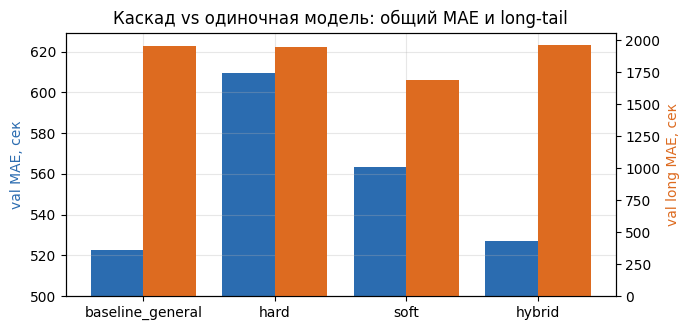

In [4]:
order = ['baseline_general', 'cascade_hard', 'cascade_soft', 'cascade_hybrid']
d = cas.set_index('model').loc[[m for m in order if m in cas.model.values]]
x = np.arange(len(d))
fig, ax1 = plt.subplots()
ax1.bar(x - 0.2, d.val_mae, 0.4, color=BLUE, label='val MAE')
ax1.set_ylim(500, d.val_mae.max() + 20); ax1.set_ylabel('val MAE, сек', color=BLUE)
ax2 = ax1.twinx(); ax2.bar(x + 0.2, d.val_long_mae, 0.4, color=ORANGE); ax2.grid(False)
ax2.set_ylabel('val long MAE, сек', color=ORANGE)
ax1.set_xticks(x); ax1.set_xticklabels([m.replace('cascade_', '') for m in d.index])
ax1.set_title('Каскад vs одиночная модель: общий MAE и long-tail'); plt.tight_layout(); plt.show()

**Вывод (честный отрицательный).** Ни один режим не обходит одиночную модель по общему MAE (ошибки классификатора распространяются); soft-режим полезен только для long-tail.

## 4.2 Коррекция остатков базовой модели
Честная схема: base на блоке A → остатки на блоке B → компактный корректор; `final = base + correction`.

In [5]:
n = len(p.x_train); cut = int(n * 0.7)
xa, ya = p.x_train.iloc[:cut], p.y_train[:cut]
xb, yb = p.x_train.iloc[cut:], p.y_train[cut:]
ta = TargetTransform('p995').fit(ya)
base_a = CatBoostRegressor(loss_function='MAE', depth=hp['depth'], learning_rate=hp['learning_rate'],
                           l2_leaf_reg=hp['l2_leaf_reg'], iterations=hp['iterations'], od_type='Iter',
                           random_seed=42, verbose=False, thread_count=-1)
base_a.fit(xa, ta.transform(ya), cat_features=cat)
resid_b = yb - ta.inverse(base_a.predict(xb))
corr = CatBoostRegressor(loss_function='MAE', depth=4, learning_rate=0.03, l2_leaf_reg=5.0,
                         iterations=400, od_type='Iter', random_seed=42, verbose=False, thread_count=-1)
corr.fit(xb, resid_b, cat_features=cat)
base_full, _, tfm = C.fit_regressor(p, hp, 'MAE', 'p995')
rows = []
for name, use_corr in [('base_only', False), ('base_plus_correction', True)]:
    r = dict(model=name)
    for split, X, y in [('val', p.x_val, p.y_val), ('test', p.x_test, p.y_test)]:
        pred = tfm.inverse(base_full.predict(X))
        if use_corr:
            pred = np.maximum(pred + corr.predict(X), 0)
        mm = C.metric_pack(y, pred)
        r[f'{split}_mae'] = mm['mae']
        if split == 'val':
            r['val_small'] = mm['small_mae']; r['val_normal'] = mm['normal_mae']; r['val_long'] = mm['long_mae']
    rows.append(r)
display(pd.DataFrame(rows))

,model,val_mae,val_small,val_normal,val_long,test_mae
0,base_only,522.534000,207.514666,322.122023,1955.531109,429.260483
1,base_plus_correction,528.587922,186.719789,355.661179,1987.053388,433.098445


**Вывод.** По общему MAE коррекция не помогает, но подтверждает систематику — улучшает small_mae (завышение коротких сессий реально есть). Диагностика, не production-приём.